Langchain version 1

In [10]:
import langchain
langchain.__version__

'1.3.14'

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

groq_key = os.getenv("GROQ_API_KEY")

#print(groq_key)

In [2]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model='openai/gpt-oss-120b',
    api_key=groq_key
)

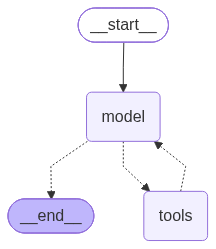

In [4]:
## create an agent

from langchain.agents import create_agent

def get_weather(city: str) -> str:
    """ Get the weather details for a given city. """

    return f"The weather in {city} is sunny."

agent = create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt='You are a helpful assistant'
)

agent

In [6]:
## run the agent

response = agent.invoke({"messages":[{"role":"user","content":"What is the weather in New York?"}]})

In [ ]:
response["messages"][-1].content  

'The weather in New\u202fYork is currently sunny. Enjoy the clear skies!'

In [9]:
agent.invoke({"messages": "What is the weather in New York?" })

{'messages': [HumanMessage(content='What is the weather in New York?', additional_kwargs={}, response_metadata={}, id='39330ab4-6a06-41da-8dfb-865aa8489e6e'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "What is the weather in New York?" We need to fetch weather using provided function get_weather with city parameter. We\'ll call function.', 'tool_calls': [{'id': 'fc_09577381-c6e0-4561-85c6-ed94fedd3b53', 'function': {'arguments': '{"city":"New York"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 139, 'total_tokens': 198, 'completion_time': 0.12425013, 'completion_tokens_details': {'reasoning_tokens': 31}, 'prompt_time': 0.005601424, 'prompt_tokens_details': None, 'queue_time': 0.150952046, 'total_time': 0.129851554}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_6c36ac20de', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model

## models integration with OpenAI, Google Gemini and GROQ

In [ ]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["OpenAI_API_KEY"] = os.getenv("OpenAI_API_KEY")

In [ ]:
from langchain.chat_models import init_chat_models

model = init_chat_models("gpt-4.1-mini")

model

In [ ]:
## invoke the model

response = model.invoke("hello how are you?")
response
response.content 

In [ ]:
## ChatOpenAI

from langchain_openai import ChatOpenAI

model = chatOPenAI = ChatOpenAI(
    model="gpt-4o-mini")

response = model.invoke("hello how are you?").content

response

## google gemini model integration


In [ ]:

from langchain.chat_models import init_chat_models

model = init_chat_models("google/gemini-1.5-turbo")

response = model.invoke("hello how are you?")
response.content

In [ ]:
## ChatGoogleGenerativeAI

import os
from langchain_google_genai import ChatGoogleGenerativeAI

chat_google_genai = ChatGoogleGenerativeAI(
    model="gemini-1.5-turbo")

response = chat_google_genai.invoke("hello how are you?").content



## Groq model integration

In [ ]:
import os
from langchain.chat_models import init_chat_models

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

chat_groq = init_chat_models("groq/gpt-oss-120b")
response = chat_groq.invoke("hello how are you?").content


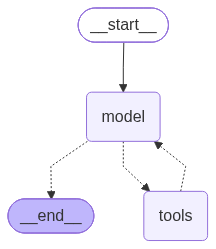

In [18]:
import os

from langchain_groq import ChatGroq

chatgroq = ChatGroq(
    model='openai/gpt-oss-120b',
    api_key=os.getenv("GROQ_API_KEY")
)

agent = create_agent(
    model=chatgroq,
    tools=[get_weather],
    system_prompt='You are a helpful assistant'
)

agent

In [2]:
import os
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

model = ChatGroq(
    model='openai/gpt-oss-120b',
    api_key=os.getenv("GROQ_API_KEY")
)

response = model.invoke("hello how are you?")
response.content

"Hello! I'm doing great, thanks for asking. How can I help you today?"

## Streaming
Most models can stream their output content while it is being generated. By displaying output progressively, streaming significantly improves user experience, particularly for longer responses. Calling stream() returns an iterator that yields output chunks as they are produced. You can use a loop to process each chunk in real-time:

In [11]:
for chunck in model.stream("write two paragraphs about the benefits of using LangChain for building AI applications."):
    print(chunck.text, end="", flush=True)

LangChain streamlines the development of AI‑driven applications by providing a modular, composable framework that abstracts away much of the boilerplate code required to connect large language models (LLMs) with external data sources, tools, and user interfaces. With built‑in support for prompt templating, memory management, and chain orchestration, developers can focus on the high‑level logic of their product rather than wrestling with low‑level API calls. This not only accelerates prototyping but also makes it easier to maintain and scale solutions, as each component—whether a retrieval module, a tool‑calling step, or a custom post‑processing function—can be swapped out or upgraded independently without rewriting the entire pipeline.

Beyond speed, LangChain enhances robustness and flexibility by offering a rich ecosystem of integrations with vector stores, databases, APIs, and even UI frameworks. Its standardized interface for chaining together multiple LLM calls enables sophisticat

## Batch
Batching a collection of independent requests to a model can significantly improve performance and reduce costs, as the processing can be done in parallel:

batch() is a LangChain method that sends multiple prompts to the model in one call.

Use invoke() when processing a single prompt. Use batch() when you have multiple independent prompts that don't depend on one another. Batch processing can improve efficiency and reduce request overhead compared to making many individual calls.

In [12]:
responses = model.batch([
    "why do parrots have colorful feathers?",
    "what is the capital of France?",
    "what is quantum computing?"
])

for response in responses:
    print(response.content)

Parrots’ bright, vivid plumage isn’t just for show—it’s the result of several evolutionary advantages that have helped the birds survive and reproduce. Here are the main reasons why many parrots sport such colorful feathers:

| Reason | How It Works | Why It Matters |
|--------|--------------|----------------|
| **Sexual selection** | Bright colors can signal good health, strong genetics, or the ability to find high‑quality food. In many species, mates prefer partners with the most striking plumage. | Increases an individual’s chances of finding a mate and passing on its genes. |
| **Species and individual identification** | Each parrot species (and sometimes even individuals) has a distinctive color pattern that helps birds recognize one another. | Reduces mistaken aggression or mating attempts with the wrong species, and helps maintain social bonds in flocks. |
| **Camouflage in a colorful environment** | Tropical forests are full of bright fruits, flowers, and dappled sunlight. Some

- max_tokens=100 → Each of the three responses can contain at most 100 output tokens.

- max_concurrency=5 → LangChain is allowed to process up to five prompts at the same time. Since your batch contains only three prompts, all three will be processed concurrently. The concurrency limit is not fully utilized in this case.

In [15]:
model.batch(
    ["why do parrots have colorful feathers?",
    "what is the capital of France?",
    "what is quantum computing?"],
    config={
        'max_tokens': 100,
        'max_concurrency': 5
    }
)

[AIMessage(content='Parrots are famous for their vivid greens, reds, blues, and yellows, and scientists think several evolutionary forces have shaped that kaleidoscopic plumage. Here’s a rundown of the main reasons:\n\n| Reason | How it works | Why it matters for parrots |\n|--------|--------------|----------------------------|\n| **Sexual selection** | Bright colors can signal good health, strong genetics, or the ability to find high‑quality food. Birds that are more conspicuous are often more attractive to potential mates. | In many parrot species (e.g., the Eclectus\u202fparrot), males and females look dramatically different, and the brighter sex gets the edge in courtship. |\n| **Species & individual recognition** | Distinct color patterns act like a visual “name tag” that helps birds identify members of their own species—and even specific flock mates—quickly in dense forests. | Parrots often live in mixed‑species flocks; a unique color signature reduces confusion and helps maintai